Project 1 
Author: Eliana Falleur
Date: April 19, 2026

Other Tools Used: ChatGPT

A.) Restating the Question

What is the overall pay of data scientists?
--distributions and median(if there is any skew)

How does experience affect salary?
--will help in my recommendation moving forward

How does pay differ in US vs Non-US?
--the question CEO was asking simplified


I came up with the basic questions and ChatGPT was helpful in outlining how these could play into my presentation

B1.) Loading the Data Frame

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("project_1_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [80]:
df.describe(include='all')

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,607.000000,607.000000,607,607,607,6.070000e+02,607,607.000000,607,607.00000,607,607
unique,NaN,NaN,4,4,50,NaN,17,NaN,57,NaN,50,3
top,NaN,NaN,SE,FT,Data Scientist,NaN,USD,NaN,US,NaN,US,M
freq,NaN,NaN,280,588,143,NaN,398,NaN,332,NaN,355,326
mean,303.000000,2021.405272,NaN,NaN,NaN,3.240001e+05,NaN,112297.869852,NaN,70.92257,NaN,NaN
std,175.370085,0.692133,NaN,NaN,NaN,1.544357e+06,NaN,70957.259411,NaN,40.70913,NaN,NaN
min,0.000000,2020.000000,NaN,NaN,NaN,4.000000e+03,NaN,2859.000000,NaN,0.00000,NaN,NaN
25%,151.500000,2021.000000,NaN,NaN,NaN,7.000000e+04,NaN,62726.000000,NaN,50.00000,NaN,NaN
50%,303.000000,2022.000000,NaN,NaN,NaN,1.150000e+05,NaN,101570.000000,NaN,100.00000,NaN,NaN
75%,454.500000,2022.000000,NaN,NaN,NaN,1.650000e+05,NaN,150000.000000,NaN,100.00000,NaN,NaN


B2.) Fixing variables

In [81]:
categorical=['experience_level','employment_type','job_title','company_size','employee_residence','company_location','company_size', 'remote_ratio']

for col in categorical:
    df[col]=df[col].astype('category')

3.) Exploratory Analysis

Variable Explanations (taken from project description 1.docx):

work_year-> years the salaries were  paid for 2020-2022

experience_level-> The experience level in the job during the year with the following possible values: EN Entry-level / Junior MI Mid-level        Intermediate SE Senior-level / Expert EX Executive-level / Director

employment_type-> The type of employement for the role: PT Part-time FT Full-time CT Contract FL Freelance

job_title->The role worked in during the year

salary->The total gross salary amount paid

salary_currency-> The currency of the salary paid as an ISO 4217 currency code

salaryinusd-> The salary in USD (FX rate divided by avg. USD rate for the respective year via
fxdata.foorilla.com)

employee_residence-> Employee's primary country of residence in during the work year as an ISO 3166
country code

remote_ratio->The overall amount of work done remotely, possible values are as follows: 0 No remotework (less than 20%) 50 Partially remote 100 Fully remote (more than 80%)

company_location->The country of the employer's main office or contracting branch as an ISO 3166 country
code

company_size->The average number of people that worked for the company during the year: S less than
50 employees (small) M 50 to 250 employees (medium) L more than 250 employees
(large)

##INDIVIDUAL VARIABLE WORK##

In [82]:
df['work_year'].describe()
#work years are between 2020 and 2022 in this data set

count     607.000000
mean     2021.405272
std         0.692133
min      2020.000000
25%      2021.000000
50%      2022.000000
75%      2022.000000
max      2022.000000
Name: work_year, dtype: float64

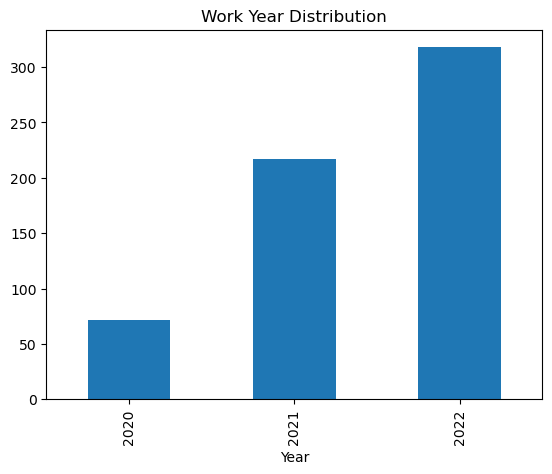

In [83]:
df['work_year'].value_counts().sort_index().plot(kind='bar')
plt.title("Work Year Distribution")
plt.xlabel("Year")
plt.show()

In [84]:
df['experience_level'].value_counts()
#majority of employees fall under Senior Executives or Mid-Level Intermediate for experience

experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64

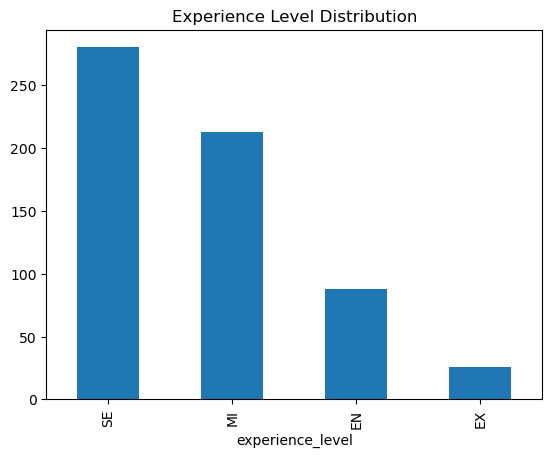

In [85]:
df['experience_level'].value_counts().plot(kind='bar')
plt.title("Experience Level Distribution")
plt.show()

In [109]:
df['employment_type'].value_counts()
#most employees are full time in this data set--97% 

employment_type
FT    588
PT     10
CT      5
FL      4
Name: count, dtype: int64

In [110]:
588/607

0.9686985172981878

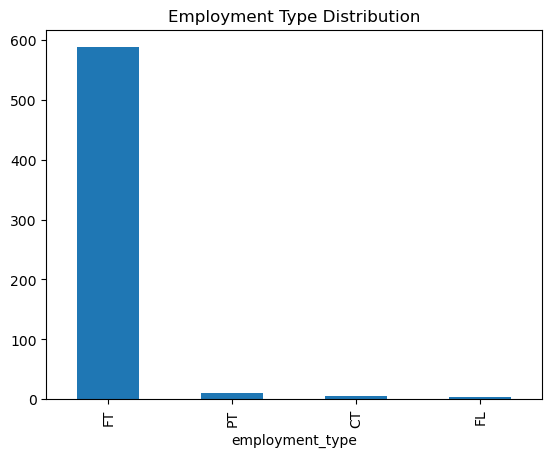

In [87]:
df['employment_type'].value_counts().plot(kind='bar')
plt.title("Employment Type Distribution")
plt.show()

In [111]:
df['job_title'].value_counts()
#the top three job titles in the data set are Data Scientist, Data Engineer, Data Analyst but there
#are still multiple other jobs that are data related just with different titles.

job_title
Data Scientist                              143
Data Engineer                               132
Data Analyst                                 97
Machine Learning Engineer                    41
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Big Data Engineer                             8
Machine Learning Scientist                    8
Director of Data Science                      7
AI Scientist                                  7
Principal Data Scientist                      7
Data Science Consultant                       7
Data Analytics Manager                        7
Computer Vision Engineer                      6
BI Data Analyst                               6
ML Engineer                                   6
Lead Data Engineer                            6
Data Engineering Manager                      5
Business Data Analyst                         5
Applied Data Scientist        

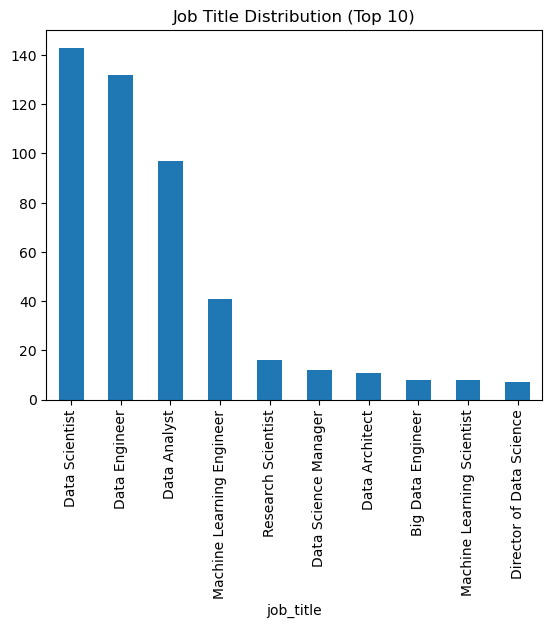

In [112]:
df['job_title'].value_counts().head(10).plot(kind='bar')
plt.title("Job Title Distribution (Top 10)")
plt.show()

In [113]:
df['salary'].describe()
#the average salary is over 300k but is a wide range because of the different currencies used

count    6.070000e+02
mean     3.240001e+05
std      1.544357e+06
min      4.000000e+03
25%      7.000000e+04
50%      1.150000e+05
75%      1.650000e+05
max      3.040000e+07
Name: salary, dtype: float64

In [114]:
df['salary_currency'].value_counts()
# majority of the salaries are in USD but there are 16 other options included in this data set

salary_currency
USD    398
EUR     95
GBP     44
INR     27
CAD     18
JPY      3
PLN      3
TRY      3
CNY      2
MXN      2
HUF      2
DKK      2
SGD      2
BRL      2
AUD      2
CLP      1
CHF      1
Name: count, dtype: int64

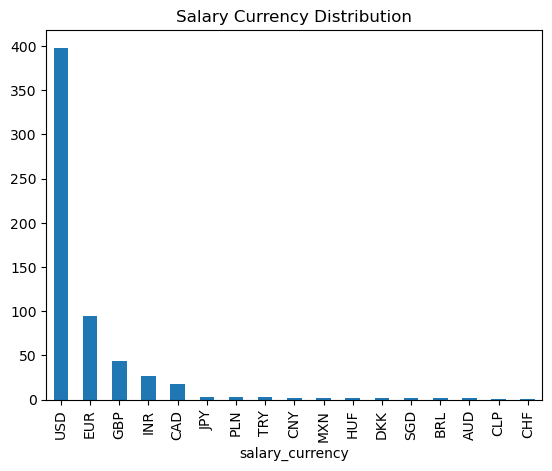

In [115]:
df['salary_currency'].value_counts().plot(kind='bar')
plt.title("Salary Currency Distribution")
plt.show()

In [116]:
df['salary_in_usd'].describe()
#the average salary once converted to USD is $112,297

count       607.000000
mean     112297.869852
std       70957.259411
min        2859.000000
25%       62726.000000
50%      101570.000000
75%      150000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

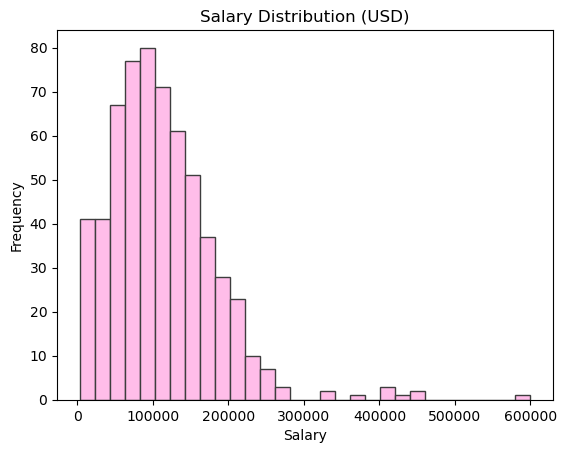

In [118]:
#####USE IN PRESENTATION###
df['salary_in_usd'].plot(kind='hist', bins=30, color='#ffbde9',edgecolor='#3d3d3d')
plt.title("Salary Distribution (USD)")
plt.xlabel("Salary")
plt.savefig("salary_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [119]:
df['employee_residence'].value_counts()
#Majority of employees live in the US but there are plenty of data employees internationally

employee_residence
US    332
GB     44
IN     30
CA     29
DE     25
FR     18
ES     15
GR     13
JP      7
PK      6
BR      6
PT      6
NL      5
IT      4
PL      4
RU      4
TR      3
AE      3
VN      3
AT      3
AU      3
BE      2
SI      2
MX      2
RO      2
SG      2
NG      2
HU      2
DK      2
TN      1
CL      1
RS      1
UA      1
BG      1
PR      1
BO      1
CH      1
PH      1
NZ      1
EE      1
MY      1
DZ      1
MT      1
MD      1
LU      1
KE      1
CN      1
JE      1
CO      1
IR      1
AR      1
CZ      1
IE      1
HR      1
HN      1
HK      1
IQ      1
Name: count, dtype: int64

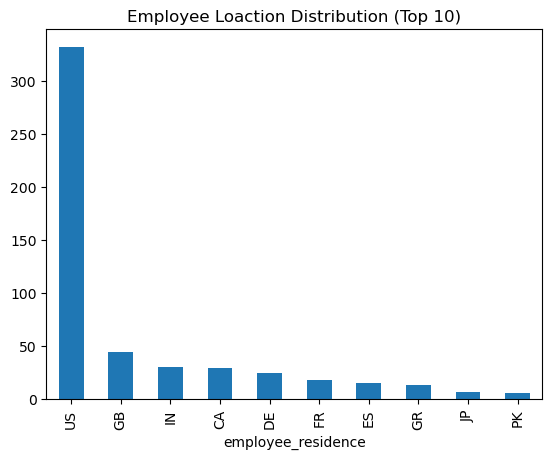

In [120]:
df['employee_residence'].value_counts().head(10).plot(kind='bar')
plt.title("Employee Loaction Distribution (Top 10)")
plt.show()

In [121]:
df['remote_ratio'].value_counts()
#majority of employees in the data field are remote

remote_ratio
100    381
0      127
50      99
Name: count, dtype: int64

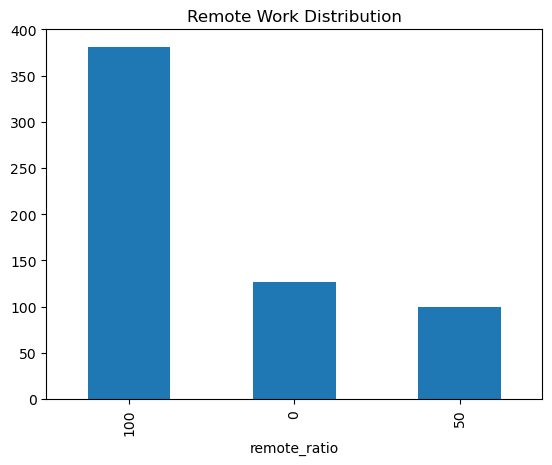

In [122]:
df['remote_ratio'].value_counts().plot(kind='bar')
plt.title("Remote Work Distribution")
plt.show()

In [123]:
df['company_location'].value_counts()
#majority of data companies also lie within the US

company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
PL      4
PT      4
NL      4
AT      4
MX      3
LU      3
TR      3
PK      3
AE      3
AU      3
BR      3
DK      3
CN      2
CZ      2
BE      2
SI      2
RU      2
NG      2
IT      2
CH      2
NZ      1
CL      1
EE      1
SG      1
UA      1
RO      1
CO      1
MY      1
DZ      1
MT      1
MD      1
KE      1
IR      1
IQ      1
AS      1
IL      1
IE      1
HU      1
HR      1
HN      1
VN      1
Name: count, dtype: int64

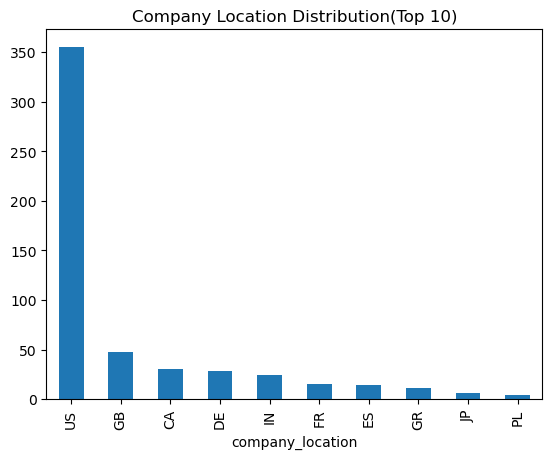

In [124]:
df['company_location'].value_counts().head(10).plot(kind='bar')
plt.title("Company Location Distribution(Top 10)")
plt.show()

In [125]:
df['company_size'].value_counts()
#most companies fall within the Medium to Large size range

company_size
M    326
L    198
S     83
Name: count, dtype: int64

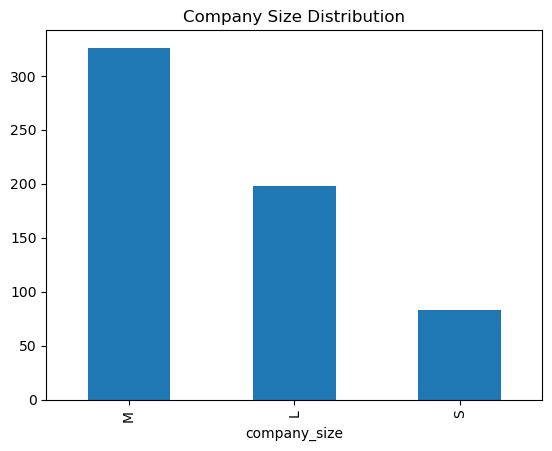

In [126]:
df['company_size'].value_counts().plot(kind='bar')
plt.title("Company Size Distribution")
plt.show()

C.) Final Data for Presentation

In [127]:
#overall pay
salary_dis_USD=df['salary_in_usd'].agg(['min', 'median', 'mean', 'max'])
salary_dis_USD

min         2859.000000
median    101570.000000
mean      112297.869852
max       600000.000000
Name: salary_in_usd, dtype: float64

In [128]:
exlevel_salary=df.groupby('experience_level', observed=False)['salary_in_usd'].agg(['median', 'mean', 'count'])
exlevel_salary

,median,mean,count
experience_level,,,
EN,56500.0,61643.318182,88
EX,171437.5,199392.038462,26
MI,76940.0,87996.056338,213
SE,135500.0,138617.292857,280


In [129]:
us_vs_nonus_sal=df['US_vs_NonUS']=df['company_location'].apply(lambda x:'US'if x=='US'else'Non-US')
us_vs_nonus_sal_usd=df.groupby('US_vs_NonUS')['salary_in_usd'].agg(['median', 'mean'])
us_vs_nonus_sal_usd

,median,mean
US_vs_NonUS,,
Non-US,62688.5,67560.273810
US,135000.0,144055.261972


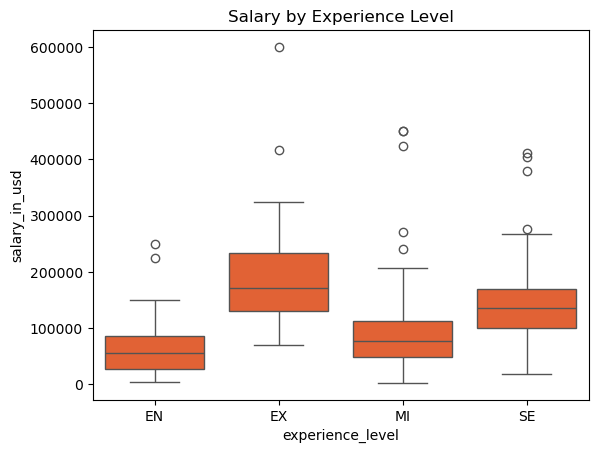

In [100]:
#experience level salaries
sns.boxplot(x='experience_level',y='salary_in_usd',data=df,color='#fe5418')
plt.title("Salary by Experience Level")
plt.savefig("salary_experience.png", dpi=300, bbox_inches='tight')
plt.show()

RECOMMENDATION

In [107]:
ranges=df.groupby('experience_level',observed=False)['salary_in_usd'].quantile([0.25, 0.75]).unstack()
ranges.columns=['25th_percentile', '75th_percentile']

print(ranges)

                  25th_percentile  75th_percentile
experience_level                                  
EN                        27505.0         85425.75
EX                       130006.5        233750.00
MI                        48000.0        112000.00
SE                       100000.0        170000.00


Overall Summary:Data scientist salaries vary a lot, with a median around $101K and a distribution where a few very high salaries pull the average up, making the median a better measure. Pay increases clearly with experience, with senior and executive roles earning the most. There is also a large gap between U.S. and non-U.S. salaries, with U.S.-based roles earning much more on average. Overall, experience and location are the main factors driving salary, supporting a hiring strategy that uses U.S.-based senior talent for leadership and offshore hires for more cost-effective growth.

References: 
ChatGPT-
I wanted to call out my use case with ChatGPT. I utilized it to hone in on how my initial questions could benefit by presentation. I also did use it for some of the coding help in times when I was stuck or unsure of how to bring the data that I needed out. For example the last 'ranges' block. I knew I needed the pieces of 25% and 75% to show a good range for hiring salaries but did not understand how to fully execute. I wanted to be transparent in this final analysis. 
    